# YOLOv11 Keypoint Detection Tutorial

## Overview

This notebook demonstrates how to use YOLOv11 for **keypoint detection** tasks. Keypoint detection involves identifying and localizing specific anatomical landmarks on objects, particularly useful for human pose estimation, animal pose analysis, and object part detection.

## What You'll Learn

1. **Keypoint Detection**: Identifying and localizing specific anatomical landmarks
2. **Keypoint Mapping**: Understanding how different keypoints correspond to body parts
3. **Visualization Techniques**: Displaying keypoint detection results effectively
4. **Pose Analysis**: Analyzing human poses and movements
5. **Google Colab Integration**: Saving and downloading results for further analysis

## Key Concepts

### Keypoint Detection
- **Purpose**: Detect and localize specific anatomical landmarks on objects
- **Output**: Bounding boxes + keypoint coordinates + visibility/confidence scores
- **Use Cases**: Human pose estimation, sports analysis, medical imaging, robotics

### Keypoint Mapping
- **COCO Pose Format**: 17 keypoints for human pose estimation
- **Keypoint Connections**: Skeleton structure connecting related keypoints
- **Visibility Scores**: Confidence that each keypoint is visible and correctly detected

## Requirements
- Python 3.8+
- PyTorch
- YOLOv11
- OpenCV
- Matplotlib
- PIL/Pillow


## Installation and Setup

First, let's install the required packages. In Google Colab, you can run these commands directly. For local environments, make sure you have Python 3.8+ installed.


In [1]:
# Install required packages
!pip install ultralytics opencv-python matplotlib pillow

# For Google Colab, also install these additional packages
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")

# Install additional packages for Colab
if IN_COLAB:
    !pip install ipywidgets
    from google.colab import files


Running locally


In [2]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from ultralytics import YOLO
import os
from pathlib import Path
import json

# Set up matplotlib for better visualization
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Check if we're in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")


Libraries imported successfully!
PyTorch version: 2.8.0
CUDA available: False
Running locally


## Part 1: Understanding Keypoint Detection with YOLOv11

### What is Keypoint Detection?

Keypoint detection is a computer vision task that involves identifying and localizing specific anatomical landmarks on objects. For human pose estimation, this typically means detecting joints like elbows, knees, shoulders, etc.

**Key Features:**
- **Object Detection**: Identifies bounding boxes and class labels
- **Keypoint Localization**: Provides precise coordinates for each anatomical landmark
- **Visibility Scores**: Confidence that each keypoint is visible and correctly detected
- **Skeleton Structure**: Understanding how keypoints connect to form a skeleton

### YOLOv11 Keypoint Models

YOLOv11 offers several pre-trained models for keypoint detection:
- `yolo11n-pose.pt` - Nano (fastest, smallest)
- `yolo11s-pose.pt` - Small
- `yolo11m-pose.pt` - Medium
- `yolo11l-pose.pt` - Large
- `yolo11x-pose.pt` - Extra Large (most accurate)

Let's start by loading a keypoint detection model and understanding the keypoint structure.


In [3]:
# Load YOLOv11 keypoint detection model
# We'll use the medium model for a good balance of speed and accuracy
model = YOLO('yolo11m-pose.pt')

print("YOLOv11 keypoint detection model loaded successfully!")
print(f"Model info: {model.info()}")

# Download a sample image for testing
# In Colab, we'll use a sample image from the web
if IN_COLAB:
    # Download a sample image with people
    !wget -q https://ultralytics.com/images/bus.jpg -O sample_image.jpg
    sample_image_path = "sample_image.jpg"
else:
    # For local testing, you can use any image
    # Create a simple test image if none exists
    if not os.path.exists("sample_image.jpg"):
        # Create a simple colored rectangle as test image
        img = np.zeros((400, 600, 3), dtype=np.uint8)
        img[100:300, 150:450] = [0, 255, 0]  # Green rectangle
        img[200:350, 200:500] = [255, 0, 0]  # Red rectangle (overlapping)
        cv2.imwrite("sample_image.jpg", img)
    sample_image_path = "sample_image.jpg"

print(f"Sample image path: {sample_image_path}")


YOLOv11 keypoint detection model loaded successfully!
YOLO11m-pose summary: 246 layers, 20,912,364 parameters, 0 gradients, 71.9 GFLOPs
Model info: (246, 20912364, 0, 71.9384576)
Sample image path: sample_image.jpg


## Part 2: Understanding COCO Keypoint Format

### COCO Pose Keypoint Structure

The COCO dataset defines 17 keypoints for human pose estimation. Each keypoint has:
- **x, y coordinates**: Pixel location in the image
- **visibility score**: 0=not visible, 1=occluded, 2=visible

Let's define the keypoint structure and skeleton connections:


In [4]:
# COCO Keypoint definitions
COCO_KEYPOINTS = {
    0: 'nose',
    1: 'left_eye',
    2: 'right_eye',
    3: 'left_ear',
    4: 'right_ear',
    5: 'left_shoulder',
    6: 'right_shoulder',
    7: 'left_elbow',
    8: 'right_elbow',
    9: 'left_wrist',
    10: 'right_wrist',
    11: 'left_hip',
    12: 'right_hip',
    13: 'left_knee',
    14: 'right_knee',
    15: 'left_ankle',
    16: 'right_ankle'
}

# Skeleton connections (pairs of keypoints that form bones)
SKELETON_CONNECTIONS = [
    # Head
    (0, 1), (0, 2),  # nose to eyes
    (1, 3), (2, 4),  # eyes to ears
    
    # Torso
    (5, 6),  # shoulders
    (5, 11), (6, 12),  # shoulders to hips
    (11, 12),  # hips
    
    # Left arm
    (5, 7), (7, 9),  # left shoulder to elbow to wrist
    
    # Right arm
    (6, 8), (8, 10),  # right shoulder to elbow to wrist
    
    # Left leg
    (11, 13), (13, 15),  # left hip to knee to ankle
    
    # Right leg
    (12, 14), (14, 16),  # right hip to knee to ankle
]

# Color scheme for different body parts
KEYPOINT_COLORS = {
    'head': (255, 0, 0),      # Red
    'torso': (0, 255, 0),    # Green
    'left_arm': (0, 0, 255), # Blue
    'right_arm': (255, 255, 0), # Cyan
    'left_leg': (255, 0, 255), # Magenta
    'right_leg': (0, 255, 255), # Yellow
}

# Assign colors to keypoints
KEYPOINT_COLOR_MAP = {
    0: KEYPOINT_COLORS['head'],    # nose
    1: KEYPOINT_COLORS['head'],    # left_eye
    2: KEYPOINT_COLORS['head'],    # right_eye
    3: KEYPOINT_COLORS['head'],    # left_ear
    4: KEYPOINT_COLORS['head'],    # right_ear
    5: KEYPOINT_COLORS['left_arm'], # left_shoulder
    6: KEYPOINT_COLORS['right_arm'], # right_shoulder
    7: KEYPOINT_COLORS['left_arm'], # left_elbow
    8: KEYPOINT_COLORS['right_arm'], # right_elbow
    9: KEYPOINT_COLORS['left_arm'], # left_wrist
    10: KEYPOINT_COLORS['right_arm'], # right_wrist
    11: KEYPOINT_COLORS['left_leg'], # left_hip
    12: KEYPOINT_COLORS['right_leg'], # right_hip
    13: KEYPOINT_COLORS['left_leg'], # left_knee
    14: KEYPOINT_COLORS['right_leg'], # right_knee
    15: KEYPOINT_COLORS['left_leg'], # left_ankle
    16: KEYPOINT_COLORS['right_leg'], # right_ankle
}

print("COCO Keypoint structure defined!")
print(f"Total keypoints: {len(COCO_KEYPOINTS)}")
print(f"Skeleton connections: {len(SKELETON_CONNECTIONS)}")

# Display keypoint information
print("\nKeypoint mapping:")
for i, name in COCO_KEYPOINTS.items():
    print(f"  {i:2d}: {name}")

print("\nSkeleton connections:")
for i, (kp1, kp2) in enumerate(SKELETON_CONNECTIONS):
    print(f"  {i+1:2d}: {COCO_KEYPOINTS[kp1]} -> {COCO_KEYPOINTS[kp2]}")


COCO Keypoint structure defined!
Total keypoints: 17
Skeleton connections: 16

Keypoint mapping:
   0: nose
   1: left_eye
   2: right_eye
   3: left_ear
   4: right_ear
   5: left_shoulder
   6: right_shoulder
   7: left_elbow
   8: right_elbow
   9: left_wrist
  10: right_wrist
  11: left_hip
  12: right_hip
  13: left_knee
  14: right_knee
  15: left_ankle
  16: right_ankle

Skeleton connections:
   1: nose -> left_eye
   2: nose -> right_eye
   3: left_eye -> left_ear
   4: right_eye -> right_ear
   5: left_shoulder -> right_shoulder
   6: left_shoulder -> left_hip
   7: right_shoulder -> right_hip
   8: left_hip -> right_hip
   9: left_shoulder -> left_elbow
  10: left_elbow -> left_wrist
  11: right_shoulder -> right_elbow
  12: right_elbow -> right_wrist
  13: left_hip -> left_knee
  14: left_knee -> left_ankle
  15: right_hip -> right_knee
  16: right_knee -> right_ankle


## Part 3: Performing Keypoint Detection

Now let's perform keypoint detection on our sample image and understand the results:


Running keypoint detection...

image 1/1 /Users/markk/Dev/git/iti121-2025s2/L8/sample_image.jpg: 640x480 4 persons, 147.7ms
Speed: 1.7ms preprocess, 147.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)


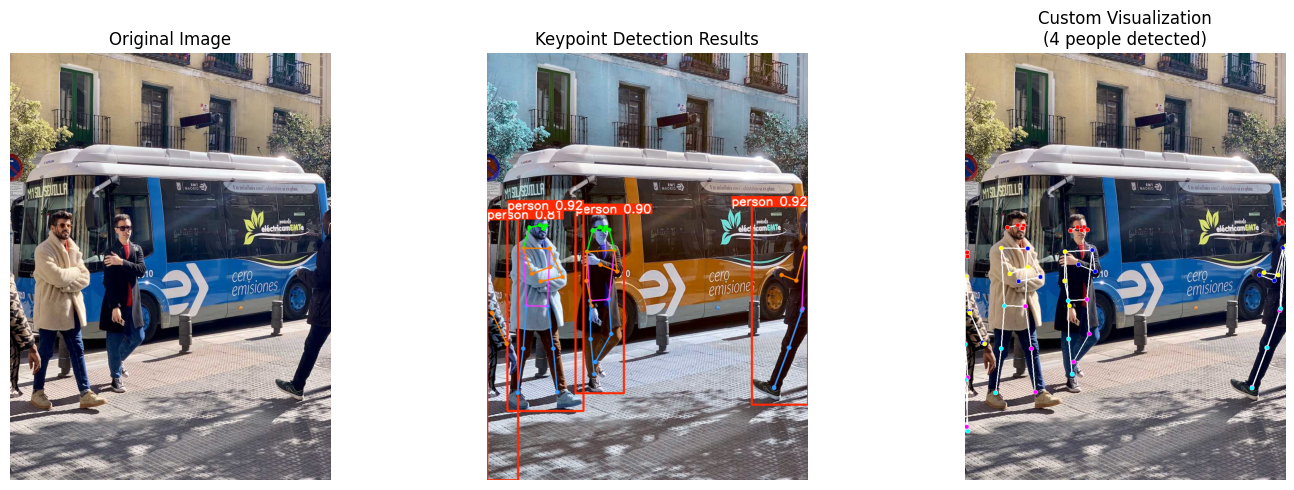


Detection Results:
Number of people detected: 4

Person 1:
  Visible keypoints: 17/17
  Keypoint visibility:
    nose: not visible at (792.3, 432.3)
    left_eye: not visible at (792.6, 424.7)
    right_eye: not visible at (792.6, 421.6)
    left_ear: not visible at (802.2, 430.6)
    right_ear: not visible at (802.0, 427.7)
    left_shoulder: not visible at (802.6, 492.2)
    right_shoulder: not visible at (810.0, 487.3)
    left_elbow: not visible at (780.5, 575.7)
    right_elbow: not visible at (790.0, 561.1)
    left_wrist: not visible at (743.0, 561.7)
    right_wrist: not visible at (754.2, 555.2)
    left_hip: not visible at (794.3, 651.4)
    right_hip: not visible at (796.6, 646.4)
    left_knee: not visible at (761.1, 745.7)
    right_knee: not visible at (762.6, 745.2)
    left_ankle: not visible at (724.6, 845.8)
    right_ankle: not visible at (724.2, 847.0)

Person 2:
  Visible keypoints: 17/17
  Keypoint visibility:
    nose: not visible at (142.9, 444.5)
    left_eye:

In [5]:
# Perform keypoint detection
print("Running keypoint detection...")
results = model(sample_image_path)

# Display the original image
plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
original_img = cv2.imread(sample_image_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis('off')

# Results with bounding boxes and keypoints
plt.subplot(1, 3, 2)
result_img = results[0].plot()
plt.imshow(result_img)
plt.title("Keypoint Detection Results")
plt.axis('off')

# Custom keypoint visualization
plt.subplot(1, 3, 3)
custom_img = original_img.copy()

if results[0].keypoints is not None and len(results[0].keypoints) > 0:
    # Draw keypoints and skeleton
    for person_keypoints in results[0].keypoints.data:
        keypoints = person_keypoints.cpu().numpy()
        
        # Draw skeleton connections
        for kp1_idx, kp2_idx in SKELETON_CONNECTIONS:
            pt1 = (int(keypoints[kp1_idx, 0]), int(keypoints[kp1_idx, 1]))
            pt2 = (int(keypoints[kp2_idx, 0]), int(keypoints[kp2_idx, 1]))
            
            # Only draw if both keypoints are visible
            if keypoints[kp1_idx, 2] > 0 and keypoints[kp2_idx, 2] > 0:
                cv2.line(custom_img, pt1, pt2, (255, 255, 255), 2)
        
        # Draw keypoints
        for i, (x, y, v) in enumerate(keypoints):
            if v > 0:  # If keypoint is visible
                color = KEYPOINT_COLOR_MAP[i]
                cv2.circle(custom_img, (int(x), int(y)), 5, color, -1)
                cv2.circle(custom_img, (int(x), int(y)), 6, (255, 255, 255), 1)

plt.imshow(custom_img)
plt.title(f"Custom Visualization\n({len(results[0].keypoints) if results[0].keypoints is not None else 0} people detected)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Print detection results
print(f"\nDetection Results:")
print(f"Number of people detected: {len(results[0].keypoints) if results[0].keypoints is not None else 0}")

if results[0].keypoints is not None:
    for i, person_keypoints in enumerate(results[0].keypoints.data):
        keypoints = person_keypoints.cpu().numpy()
        visible_keypoints = np.sum(keypoints[:, 2] > 0)
        print(f"\nPerson {i+1}:")
        print(f"  Visible keypoints: {visible_keypoints}/17")
        print(f"  Keypoint visibility:")
        
        for j, (x, y, v) in enumerate(keypoints):
            status = "visible" if v == 2 else "occluded" if v == 1 else "not visible"
            print(f"    {COCO_KEYPOINTS[j]}: {status} at ({x:.1f}, {y:.1f})")


## Part 4: Advanced Keypoint Visualization

Let's create more sophisticated visualization functions to better understand keypoint detection results:


In [ ]:
def visualize_keypoints_detailed(image_path, results, person_idx=0):
    """
    Create a detailed visualization of keypoint detection results
    
    Args:
        image_path: Path to original image
        results: YOLO results object
        person_idx: Index of person to visualize (0-based)
    
    Returns:
        fig: matplotlib figure object
    """
    # Load original image
    original_img = cv2.imread(image_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Original image
    axes[0, 0].imshow(original_img)
    axes[0, 0].set_title("Original Image", fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    # YOLO default visualization
    yolo_result = results[0].plot()
    axes[0, 1].imshow(yolo_result)
    axes[0, 1].set_title("YOLO Default Visualization", fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    
    # Custom skeleton visualization
    skeleton_img = original_img.copy()
    
    if results[0].keypoints is not None and len(results[0].keypoints) > person_idx:
        person_keypoints = results[0].keypoints.data[person_idx].cpu().numpy()
        
        # Draw skeleton with different colors for different body parts
        skeleton_colors = {
            'head': (255, 0, 0),      # Red
            'torso': (0, 255, 0),    # Green
            'left_arm': (0, 0, 255), # Blue
            'right_arm': (255, 255, 0), # Cyan
            'left_leg': (255, 0, 255), # Magenta
            'right_leg': (0, 255, 255), # Yellow
        }
        
        # Define skeleton connections with body part labels
        skeleton_parts = {
            'head': [(0, 1), (0, 2), (1, 3), (2, 4)],
            'torso': [(5, 6), (5, 11), (6, 12), (11, 12)],
            'left_arm': [(5, 7), (7, 9)],
            'right_arm': [(6, 8), (8, 10)],
            'left_leg': [(11, 13), (13, 15)],
            'right_leg': [(12, 14), (14, 16)]
        }
        
        # Draw skeleton parts
        for part_name, connections in skeleton_parts.items():
            color = skeleton_colors[part_name]
            for kp1_idx, kp2_idx in connections:
                pt1 = (int(person_keypoints[kp1_idx, 0]), int(person_keypoints[kp1_idx, 1]))
                pt2 = (int(person_keypoints[kp2_idx, 0]), int(person_keypoints[kp2_idx, 1]))
                
                # Only draw if both keypoints are visible
                if person_keypoints[kp1_idx, 2] > 0 and person_keypoints[kp2_idx, 2] > 0:
                    cv2.line(skeleton_img, pt1, pt2, color, 3)
        
        # Draw keypoints
        for i, (x, y, v) in enumerate(person_keypoints):
            if v > 0:  # If keypoint is visible
                color = KEYPOINT_COLOR_MAP[i]
                cv2.circle(skeleton_img, (int(x), int(y)), 6, color, -1)
                cv2.circle(skeleton_img, (int(x), int(y)), 7, (255, 255, 255), 2)
                
                # Add keypoint labels
                cv2.putText(skeleton_img, str(i), (int(x)+8, int(y)-8), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    
    axes[1, 0].imshow(skeleton_img)
    axes[1, 0].set_title(f"Detailed Skeleton Visualization\nPerson {person_idx+1}", fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    
    # Keypoint information table
    axes[1, 1].axis('off')
    
    if results[0].keypoints is not None and len(results[0].keypoints) > person_idx:
        person_keypoints = results[0].keypoints.data[person_idx].cpu().numpy()
        
        # Create keypoint information
        keypoint_info = []
        for i, (x, y, v) in enumerate(person_keypoints):
            status = "✓" if v == 2 else "◐" if v == 1 else "✗"
            keypoint_info.append(f"{i:2d}. {COCO_KEYPOINTS[i]:15s} {status} ({x:5.1f}, {y:5.1f})")
        
        # Display keypoint information
        info_text = "\n".join(keypoint_info)
        axes[1, 1].text(0.05, 0.95, f"Keypoint Information (Person {person_idx+1}):\n\n{info_text}", 
                        transform=axes[1, 1].transAxes, fontsize=9, 
                        verticalalignment='top', fontfamily='monospace')
        
        # Add legend
        legend_text = "\nLegend:\n✓ Visible\n◐ Occluded\n✗ Not visible"
        axes[1, 1].text(0.05, 0.05, legend_text, transform=axes[1, 1].transAxes, 
                        fontsize=9, verticalalignment='bottom', 
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
    else:
        axes[1, 1].text(0.5, 0.5, f"No person detected at index {person_idx}", 
                        transform=axes[1, 1].transAxes, ha='center', va='center',
                        fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    return fig

# Create detailed visualization
print("Creating detailed keypoint visualization...")
fig = visualize_keypoints_detailed(sample_image_path, results, person_idx=0)
plt.show()


## Part 5: Keypoint Analysis and Pose Estimation

Now let's create functions to analyze poses and extract meaningful information from keypoint detections:


In [ ]:
def calculate_pose_angles(keypoints):
    """
    Calculate joint angles from keypoint coordinates
    
    Args:
        keypoints: Array of shape (17, 3) with [x, y, visibility]
    
    Returns:
        angles: Dictionary with joint angles
    """
    angles = {}
    
    def angle_between_points(p1, p2, p3):
        """Calculate angle at p2 between p1-p2-p3"""
        if p1[2] == 0 or p2[2] == 0 or p3[2] == 0:
            return None  # Not all points visible
        
        # Vector from p2 to p1
        v1 = np.array([p1[0] - p2[0], p1[1] - p2[1]])
        # Vector from p2 to p3
        v2 = np.array([p3[0] - p2[0], p3[1] - p2[1]])
        
        # Calculate angle
        cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        cos_angle = np.clip(cos_angle, -1.0, 1.0)  # Avoid numerical errors
        angle = np.arccos(cos_angle)
        
        return np.degrees(angle)
    
    # Calculate key joint angles
    joint_angles = {
        'left_elbow': (5, 7, 9),      # shoulder-elbow-wrist
        'right_elbow': (6, 8, 10),
        'left_shoulder': (11, 5, 7),   # hip-shoulder-elbow
        'right_shoulder': (12, 6, 8),
        'left_knee': (11, 13, 15),    # hip-knee-ankle
        'right_knee': (12, 14, 16),
        'left_hip': (5, 11, 13),      # shoulder-hip-knee
        'right_hip': (6, 12, 14)
    }
    
    for joint_name, (p1_idx, p2_idx, p3_idx) in joint_angles.items():
        angle = angle_between_points(keypoints[p1_idx], keypoints[p2_idx], keypoints[p3_idx])
        angles[joint_name] = angle
    
    return angles

def analyze_pose_stability(keypoints):
    """
    Analyze pose stability and balance
    
    Args:
        keypoints: Array of shape (17, 3) with [x, y, visibility]
    
    Returns:
        stability_info: Dictionary with stability metrics
    """
    stability_info = {}
    
    # Check if feet are visible
    left_ankle_visible = keypoints[15, 2] > 0
    right_ankle_visible = keypoints[16, 2] > 0
    
    if left_ankle_visible and right_ankle_visible:
        # Calculate base of support width
        left_ankle = keypoints[15, :2]
        right_ankle = keypoints[16, :2]
        base_width = abs(right_ankle[0] - left_ankle[0])
        stability_info['base_width'] = base_width
        stability_info['feet_visible'] = True
    else:
        stability_info['feet_visible'] = False
    
    # Check if hips are visible
    left_hip_visible = keypoints[11, 2] > 0
    right_hip_visible = keypoints[12, 2] > 0
    
    if left_hip_visible and right_hip_visible:
        # Calculate hip alignment
        left_hip = keypoints[11, :2]
        right_hip = keypoints[12, :2]
        hip_height_diff = abs(right_hip[1] - left_hip[1])
        stability_info['hip_height_diff'] = hip_height_diff
        stability_info['hips_visible'] = True
    else:
        stability_info['hips_visible'] = False
    
    return stability_info

def detect_pose_type(keypoints, angles):
    """
    Detect basic pose types based on keypoint positions and angles
    
    Args:
        keypoints: Array of shape (17, 3) with [x, y, visibility]
        angles: Dictionary with joint angles
    
    Returns:
        pose_type: String describing the detected pose
    """
    pose_indicators = []
    
    # Check arm positions
    if angles.get('left_elbow') is not None and angles.get('right_elbow') is not None:
        avg_elbow_angle = (angles['left_elbow'] + angles['right_elbow']) / 2
        if avg_elbow_angle < 90:
            pose_indicators.append("arms_extended")
        elif avg_elbow_angle > 150:
            pose_indicators.append("arms_bent")
    
    # Check leg positions
    if angles.get('left_knee') is not None and angles.get('right_knee') is not None:
        avg_knee_angle = (angles['left_knee'] + angles['right_knee']) / 2
        if avg_knee_angle < 90:
            pose_indicators.append("legs_bent")
        elif avg_knee_angle > 160:
            pose_indicators.append("legs_straight")
    
    # Check standing vs sitting
    if keypoints[11, 2] > 0 and keypoints[13, 2] > 0:  # Left hip and knee visible
        hip_knee_height_diff = keypoints[11, 1] - keypoints[13, 1]
        if hip_knee_height_diff < 50:  # Hip and knee at similar height
            pose_indicators.append("sitting")
        else:
            pose_indicators.append("standing")
    
    # Combine indicators
    if not pose_indicators:
        return "unknown_pose"
    
    return "_".join(pose_indicators)

# Analyze poses for all detected people
print("Analyzing poses...")

if results[0].keypoints is not None:
    for i, person_keypoints in enumerate(results[0].keypoints.data):
        keypoints = person_keypoints.cpu().numpy()
        
        print(f"\n{'='*50}")
        print(f"PERSON {i+1} ANALYSIS")
        print(f"{'='*50}")
        
        # Calculate joint angles
        angles = calculate_pose_angles(keypoints)
        print("\nJoint Angles:")
        for joint, angle in angles.items():
            if angle is not None:
                print(f"  {joint:15s}: {angle:6.1f}°")
            else:
                print(f"  {joint:15s}: Not visible")
        
        # Analyze stability
        stability = analyze_pose_stability(keypoints)
        print("\nStability Analysis:")
        for metric, value in stability.items():
            if isinstance(value, bool):
                print(f"  {metric:15s}: {'Yes' if value else 'No'}")
            else:
                print(f"  {metric:15s}: {value:.1f} pixels")
        
        # Detect pose type
        pose_type = detect_pose_type(keypoints, angles)
        print(f"\nDetected Pose Type: {pose_type}")
else:
    print("No people detected for pose analysis.")


## Part 6: Interactive Keypoint Visualization

Let's create an interactive visualization that allows you to explore different people and their keypoints:


In [ ]:
def create_interactive_keypoint_visualization(image_path, results):
    """
    Create an interactive visualization showing all detected people
    
    Args:
        image_path: Path to original image
        results: YOLO results object
    
    Returns:
        fig: matplotlib figure object
    """
    # Load original image
    original_img = cv2.imread(image_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    num_people = len(results[0].keypoints) if results[0].keypoints is not None else 0
    
    if num_people == 0:
        print("No people detected in the image.")
        return None
    
    # Create figure with subplots for each person
    cols = min(3, num_people)
    rows = (num_people + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 6*rows))
    if num_people == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes
    else:
        axes = axes.flatten()
    
    for i in range(num_people):
        person_img = original_img.copy()
        person_keypoints = results[0].keypoints.data[i].cpu().numpy()
        
        # Draw skeleton
        for kp1_idx, kp2_idx in SKELETON_CONNECTIONS:
            pt1 = (int(person_keypoints[kp1_idx, 0]), int(person_keypoints[kp1_idx, 1]))
            pt2 = (int(person_keypoints[kp2_idx, 0]), int(person_keypoints[kp2_idx, 1]))
            
            if person_keypoints[kp1_idx, 2] > 0 and person_keypoints[kp2_idx, 2] > 0:
                cv2.line(person_img, pt1, pt2, (255, 255, 255), 2)
        
        # Draw keypoints
        for j, (x, y, v) in enumerate(person_keypoints):
            if v > 0:
                color = KEYPOINT_COLOR_MAP[j]
                cv2.circle(person_img, (int(x), int(y)), 4, color, -1)
                cv2.circle(person_img, (int(x), int(y)), 5, (255, 255, 255), 1)
        
        # Calculate pose analysis
        angles = calculate_pose_angles(person_keypoints)
        stability = analyze_pose_stability(person_keypoints)
        pose_type = detect_pose_type(person_keypoints, angles)
        
        # Count visible keypoints
        visible_count = np.sum(person_keypoints[:, 2] > 0)
        
        axes[i].imshow(person_img)
        axes[i].set_title(f"Person {i+1}\n{visible_count}/17 keypoints visible\nPose: {pose_type}", 
                         fontsize=12, fontweight='bold')
        axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(num_people, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    return fig

# Create interactive visualization
print("Creating interactive keypoint visualization...")
fig = create_interactive_keypoint_visualization(sample_image_path, results)
if fig is not None:
    plt.show()

# Create a summary table of all detected people
if results[0].keypoints is not None and len(results[0].keypoints) > 0:
    print("\n" + "="*80)
    print("SUMMARY OF ALL DETECTED PEOPLE")
    print("="*80)
    
    summary_data = []
    for i, person_keypoints in enumerate(results[0].keypoints.data):
        keypoints = person_keypoints.cpu().numpy()
        visible_count = np.sum(keypoints[:, 2] > 0)
        occluded_count = np.sum(keypoints[:, 2] == 1)
        
        angles = calculate_pose_angles(keypoints)
        stability = analyze_pose_stability(keypoints)
        pose_type = detect_pose_type(keypoints, angles)
        
        summary_data.append({
            'person': i+1,
            'visible_keypoints': visible_count,
            'occluded_keypoints': occluded_count,
            'pose_type': pose_type,
            'feet_visible': stability.get('feet_visible', False),
            'hips_visible': stability.get('hips_visible', False)
        })
    
    # Print summary table
    print(f"{'Person':<8} {'Visible':<8} {'Occluded':<9} {'Pose Type':<20} {'Feet':<6} {'Hips':<6}")
    print("-" * 80)
    for data in summary_data:
        print(f"{data['person']:<8} {data['visible_keypoints']:<8} {data['occluded_keypoints']:<9} "
              f"{data['pose_type']:<20} {'Yes' if data['feet_visible'] else 'No':<6} "
              f"{'Yes' if data['hips_visible'] else 'No':<6}")


## Part 7: Saving and Exporting Results

Let's create functions to save keypoint detection results in various formats:


In [ ]:
def save_keypoint_results(image_path, results, output_dir="keypoint_results"):
    """
    Save keypoint detection results in various formats
    
    Args:
        image_path: Path to input image
        results: YOLO results object
        output_dir: Directory to save results
    
    Returns:
        Dictionary with paths to saved files
    """
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Load original image
    original_img = cv2.imread(image_path)
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    saved_files = {}
    
    # 1. Save YOLO default visualization
    yolo_result = results[0].plot()
    yolo_path = os.path.join(output_dir, "yolo_keypoint_detection.jpg")
    cv2.imwrite(yolo_path, yolo_result)
    saved_files['yolo_visualization'] = yolo_path
    print(f"✓ Saved: {yolo_path}")
    
    # 2. Save detailed skeleton visualization
    if results[0].keypoints is not None and len(results[0].keypoints) > 0:
        skeleton_img = original_img_rgb.copy()
        
        for person_keypoints in results[0].keypoints.data:
            keypoints = person_keypoints.cpu().numpy()
            
            # Draw skeleton with different colors for different body parts
            skeleton_colors = {
                'head': (255, 0, 0),      # Red
                'torso': (0, 255, 0),    # Green
                'left_arm': (0, 0, 255), # Blue
                'right_arm': (255, 255, 0), # Cyan
                'left_leg': (255, 0, 255), # Magenta
                'right_leg': (0, 255, 255), # Yellow
            }
            
            # Define skeleton connections with body part labels
            skeleton_parts = {
                'head': [(0, 1), (0, 2), (1, 3), (2, 4)],
                'torso': [(5, 6), (5, 11), (6, 12), (11, 12)],
                'left_arm': [(5, 7), (7, 9)],
                'right_arm': [(6, 8), (8, 10)],
                'left_leg': [(11, 13), (13, 15)],
                'right_leg': [(12, 14), (14, 16)]
            }
            
            # Draw skeleton parts
            for part_name, connections in skeleton_parts.items():
                color = skeleton_colors[part_name]
                for kp1_idx, kp2_idx in connections:
                    pt1 = (int(keypoints[kp1_idx, 0]), int(keypoints[kp1_idx, 1]))
                    pt2 = (int(keypoints[kp2_idx, 0]), int(keypoints[kp2_idx, 1]))
                    
                    if keypoints[kp1_idx, 2] > 0 and keypoints[kp2_idx, 2] > 0:
                        cv2.line(skeleton_img, pt1, pt2, color, 3)
            
            # Draw keypoints
            for i, (x, y, v) in enumerate(keypoints):
                if v > 0:
                    color = KEYPOINT_COLOR_MAP[i]
                    cv2.circle(skeleton_img, (int(x), int(y)), 6, color, -1)
                    cv2.circle(skeleton_img, (int(x), int(y)), 7, (255, 255, 255), 2)
        
        skeleton_path = os.path.join(output_dir, "detailed_skeleton.jpg")
        cv2.imwrite(skeleton_path, cv2.cvtColor(skeleton_img, cv2.COLOR_RGB2BGR))
        saved_files['detailed_skeleton'] = skeleton_path
        print(f"✓ Saved: {skeleton_path}")
    
    # 3. Save keypoint data as JSON
    keypoint_data = {
        'image_path': image_path,
        'num_people': len(results[0].keypoints) if results[0].keypoints is not None else 0,
        'keypoint_definitions': COCO_KEYPOINTS,
        'skeleton_connections': SKELETON_CONNECTIONS,
        'people': []
    }
    
    if results[0].keypoints is not None:
        for i, person_keypoints in enumerate(results[0].keypoints.data):
            keypoints = person_keypoints.cpu().numpy()
            
            person_data = {
                'person_id': i,
                'keypoints': [],
                'analysis': {}
            }
            
            # Add keypoint coordinates
            for j, (x, y, v) in enumerate(keypoints):
                person_data['keypoints'].append({
                    'id': j,
                    'name': COCO_KEYPOINTS[j],
                    'x': float(x),
                    'y': float(y),
                    'visibility': int(v),
                    'visible': v > 0
                })
            
            # Add pose analysis
            angles = calculate_pose_angles(keypoints)
            stability = analyze_pose_stability(keypoints)
            pose_type = detect_pose_type(keypoints, angles)
            
            person_data['analysis'] = {
                'joint_angles': {k: float(v) if v is not None else None for k, v in angles.items()},
                'stability': {k: float(v) if isinstance(v, (int, float)) else v for k, v in stability.items()},
                'pose_type': pose_type,
                'visible_keypoints': int(np.sum(keypoints[:, 2] > 0))
            }
            
            keypoint_data['people'].append(person_data)
    
    json_path = os.path.join(output_dir, "keypoint_data.json")
    with open(json_path, 'w') as f:
        json.dump(keypoint_data, f, indent=2)
    saved_files['keypoint_data'] = json_path
    print(f"✓ Saved: {json_path}")
    
    # 4. Save comprehensive visualization
    comprehensive_path = os.path.join(output_dir, "comprehensive_keypoint_analysis.jpg")
    fig = visualize_keypoints_detailed(image_path, results, person_idx=0)
    fig.savefig(comprehensive_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    saved_files['comprehensive_analysis'] = comprehensive_path
    print(f"✓ Saved: {comprehensive_path}")
    
    return saved_files

# Save all results
print("Saving keypoint detection results...")
saved_files = save_keypoint_results(sample_image_path, results, output_dir="keypoint_results")

print("\n" + "="*60)
print("All keypoint results saved successfully!")
print("="*60)

# Display saved files
print("\nSaved files:")
for key, path in saved_files.items():
    print(f"  {key}: {path}")

# Download files in Colab
if IN_COLAB:
    print("\nDownloading files...")
    download_results(list(saved_files.values()))


## Part 8: Working with Your Own Images

### Upload and Process Custom Images

Now that you understand how YOLOv11 keypoint detection works, let's create a simple interface to process your own images:


In [ ]:
# Function to process custom images
def process_custom_keypoint_image(image_path, conf_threshold=0.25, save_results=True):
    """
    Process a custom image with YOLOv11 keypoint detection
    
    Args:
        image_path: Path to the image file
        conf_threshold: Confidence threshold for detections
        save_results: Whether to save results to disk
    
    Returns:
        Dictionary containing results and analysis
    """
    print(f"Processing image: {image_path}")
    
    # Run keypoint detection
    results = model(image_path, conf=conf_threshold)
    
    # Create visualization
    fig = create_interactive_keypoint_visualization(image_path, results)
    if fig is not None:
        plt.show()
    
    # Print statistics
    num_people = len(results[0].keypoints) if results[0].keypoints is not None else 0
    print(f"\n📊 Detection Statistics:")
    print(f"   Total people detected: {num_people}")
    
    if num_people > 0:
        print(f"\n   Detailed Analysis:")
        for i, person_keypoints in enumerate(results[0].keypoints.data):
            keypoints = person_keypoints.cpu().numpy()
            visible_count = np.sum(keypoints[:, 2] > 0)
            occluded_count = np.sum(keypoints[:, 2] == 1)
            
            angles = calculate_pose_angles(keypoints)
            stability = analyze_pose_stability(keypoints)
            pose_type = detect_pose_type(keypoints, angles)
            
            print(f"\n   Person {i+1}:")
            print(f"     Visible keypoints: {visible_count}/17")
            print(f"     Occluded keypoints: {occluded_count}")
            print(f"     Pose type: {pose_type}")
            print(f"     Feet visible: {'Yes' if stability.get('feet_visible', False) else 'No'}")
            print(f"     Hips visible: {'Yes' if stability.get('hips_visible', False) else 'No'}")
    else:
        print("\n⚠️  No people detected in the image.")
    
    # Save results if requested
    if save_results and num_people > 0:
        output_dir = f"keypoint_results_{Path(image_path).stem}"
        saved_files = save_keypoint_results(image_path, results, output_dir=output_dir)
        print(f"\n💾 Results saved to: {output_dir}/")
        
        return {'results': results, 'saved_files': saved_files}
    
    return {'results': results}

# Example: Process the sample image
print("="*60)
print("Processing sample image with keypoint detection")
print("="*60)
result_data = process_custom_keypoint_image(sample_image_path, conf_threshold=0.25, save_results=False)


## Part 9: Upload Your Own Images (Google Colab)

### Upload and Process Your Images

If you're running this in Google Colab, you can upload your own images and process them!


In [ ]:
# Upload custom images in Google Colab
if IN_COLAB:
    from google.colab import files
    
    print("📤 Upload your image files:")
    uploaded = files.upload()
    
    # Process each uploaded image
    for filename in uploaded.keys():
        print(f"\n{'='*60}")
        print(f"Processing uploaded image: {filename}")
        print('='*60)
        
        # Process the image
        result_data = process_custom_keypoint_image(filename, conf_threshold=0.25, save_results=True)
        
        # Offer to download results
        if 'saved_files' in result_data:
            print("\n📥 Download results?")
            download_results(list(result_data['saved_files'].values()))
else:
    print("To upload custom images, run this notebook in Google Colab!")
    print("\nFor local use, you can process any image by calling:")
    print("  process_custom_keypoint_image('path/to/your/image.jpg')")
